In [13]:
# 1. Read Raw Data
import re
import os
import numpy as np
import pandas as pd
import scipy.stats as stats

# Read the raw Phase 2 survey data
df = pd.read_csv("../data/raw/survey2.csv")

print("Raw data shape:", df.shape)
print("Raw data loaded from: ../data/raw/survey2.csv")


Raw data shape: (59, 21)
Raw data loaded from: ../data/raw/survey2.csv


In [14]:
# 2. Clean and Prepare Data

# Define short column mapping using index positions
short_cols = {
    df.columns[0]: 'timestamp',
    df.columns[1]: 'consent',
    df.columns[2]: 'role',
    df.columns[3]: 'academic_level',
    df.columns[4]: 'university',
    df.columns[5]: 'field',
    df.columns[6]: 'sus_q1',
    df.columns[7]: 'sus_q2',
    df.columns[8]: 'sus_q3',
    df.columns[9]: 'sus_q4',
    df.columns[10]: 'sus_q5',
    df.columns[11]: 'sus_q6',
    df.columns[12]: 'sus_q7',
    df.columns[13]: 'sus_q8',
    df.columns[14]: 'sus_q9',
    df.columns[15]: 'sus_q10',
    df.columns[16]: 'feedback_confusing',
    df.columns[17]: 'feedback_liked',
    df.columns[18]: 'task1_announcements',
    df.columns[19]: 'task2_messaging',
    df.columns[20]: 'task3_ease',
}

# Apply column renaming
df = df.rename(columns=short_cols)


# Clean and parse numeric SUS ratings (1 to 5)
def extract_rating(val):
  if pd.isna(val):
    return np.nan
  val_str = str(val)
  match = re.search(r'\((\d+)\)', val_str)
  if match:
    return int(match.group(1))
  mapping = {
    'Strongly Disagree': 1,
    'Strongly Agree': 5,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
  }
  for k, v in mapping.items():
    if k in val_str:
      return v
  return np.nan


sus_item_cols = [f'sus_q{i}' for i in range(1, 11)]
for col in sus_item_cols:
  df[col] = df[col].apply(extract_rating)


# Compute 0-100 individual SUS Scores using short columns
def calc_sus_score(row):
  scores = []
  for i in range(1, 11):
    val = row[f'sus_q{i}']
    if pd.isna(val):
      return np.nan
    # Odd items: val - 1 | Even items: 5 - val
    scores.append((val - 1) if i % 2 != 0 else (5 - val))
  return sum(scores) * 2.5


df['sus_score'] = df.apply(calc_sus_score, axis=1)

# Save cleaned data
os.makedirs("../data/cleaned", exist_ok=True)
df.to_csv("../data/cleaned/survey2_cleaned.csv", index=False)

print("Cleaned data shape:", df.shape)
print("Cleaned data saved to: ../data/cleaned/survey2_cleaned.csv")


Cleaned data shape: (59, 22)
Cleaned data saved to: ../data/cleaned/survey2_cleaned.csv


In [15]:
# 3. Consistency Check: Internal Consistency Reliability (Cronbach's Alpha)

# Reverse-score even items (2, 4, 6, 8, 10) so all 10 items align toward positive usability
sus_aligned = pd.DataFrame()
for i in range(1, 11):
  col = f'sus_q{i}'
  if i % 2 != 0:
    sus_aligned[col] = df[col] - 1  # 0 to 4 scale (Positive orientation)
  else:
    sus_aligned[col] = 5 - df[col]  # 0 to 4 scale (Reverse-scored)


def calculate_cronbach(df_items):
  clean_df = df_items.dropna()
  k = clean_df.shape[1]

  # Raw Cronbach's Alpha (sample variance based)
  item_vars = clean_df.var(axis=0, ddof=1).sum()
  total_var = clean_df.sum(axis=1).var(ddof=1)
  alpha_raw = (k / (k - 1)) * (1 - (item_vars / total_var))

  # Standardized Cronbach's Alpha
  corr_matrix = clean_df.corr()
  mean_r = (corr_matrix.values.sum() - k) / (k * (k - 1))
  alpha_std = (k * mean_r) / (1 + (k - 1) * mean_r)

  return alpha_raw, alpha_std, mean_r


rq3_raw, rq3_std, rq3_r = calculate_cronbach(sus_aligned)

print('\n' + '=' * 65)
print('         RQ3 RELIABILITY ANALYSIS (SUS SCALE, 10 ITEMS)          ')
print('=' * 65)
print(f'Sample Size (N):                 {len(sus_aligned.dropna())}')
print(f"Cronbach's Alpha (α):            {rq3_raw:.3f}")
print(f'Standardized Alpha:              {rq3_std:.3f}')
print(f'Mean Inter-Item Correlation:     {rq3_r:.3f}')

# Save reliability result
reliability_results = pd.DataFrame({
    "Measure": [
        "Sample Size",
        "Cronbach's Alpha",
        "Standardized Alpha",
        "Mean Inter-Item Correlation"
    ],
    "Value": [
        len(sus_aligned.dropna()),
        rq3_raw,
        rq3_std,
        rq3_r
    ]
})
reliability_results.to_csv(
    "../outputs/tables/phase2/rq3_reliability_results.csv",
    index=False
)



         RQ3 RELIABILITY ANALYSIS (SUS SCALE, 10 ITEMS)          
Sample Size (N):                 59
Cronbach's Alpha (α):            0.848
Standardized Alpha:              0.848
Mean Inter-Item Correlation:     0.358


In [16]:
# 4. Descriptive Results and Test-Selection Information

clean_sus = df['sus_score'].dropna()

# Data shape
data_shape = pd.DataFrame({
    "Dataset": ["Cleaned Phase 2 survey data", "Valid SUS scores"],
    "Rows": [len(df), len(clean_sus)],
    "Columns": [len(df.columns), 1]
})
print('=' * 65)
print('                 DATA SHAPE / DESCRIPTIVE SUMMARY                 ')
print('=' * 65)
print(data_shape.to_string(index=False))

# Aggregate SUS Statistics & RQ3 Verdict
mean_sus = clean_sus.mean()
sd_sus = clean_sus.std()
median_sus = clean_sus.median()
iqr_sus = clean_sus.quantile(0.75) - clean_sus.quantile(0.25)
ci95_low, ci95_high = stats.t.interval(
    0.95, len(clean_sus) - 1, loc=mean_sus, scale=stats.sem(clean_sus)
)

print('\n' + '=' * 65)
print('         USABILITY EVALUATION RESULTS (USING SHORT COLS)         ')
print('=' * 65)
print(f'Sample Size (N):           {len(clean_sus)}')
print(f'Mean SUS Score:            {mean_sus:.2f}')
print(f'Standard Deviation (SD):   {sd_sus:.2f}')
print(f'Median SUS Score:          {median_sus:.2f}')
print(f'Interquartile Range (IQR): {iqr_sus:.2f}')
print(f'95% Confidence Interval:   [{ci95_low:.2f}, {ci95_high:.2f}]')
print(f'Benchmark Threshold:       68.00')
print(
    f"Descriptive Verdict:       {'DEFENDED' if mean_sus > 68 else 'NOT DEFENDED'}"
)

# Item Breakdown using Shortened Item Names
print('\n' + '=' * 65)
print('                 INDIVIDUAL SUS ITEM BREAKDOWN                   ')
print('=' * 65)

item_stats = []
for i in range(1, 11):
  col_name = f'sus_q{i}'
  item_stats.append({
      'Short Column': col_name,
      'Mean Rating': round(df[col_name].mean(), 2),
      'SD': round(df[col_name].std(), 2),
  })

print(pd.DataFrame(item_stats).to_string(index=False))

# Task Success & Perception Proportions using Short Columns
print('\n' + '=' * 65)
print('              TASK COMPLETION METRICS PROPORTIONS (%)            ')
print('=' * 65)

task_tables = {}
for task_col in ['task1_announcements', 'task2_messaging', 'task3_ease']:
    task_tables[task_col] = (
        df[task_col].value_counts(normalize=True) * 100
    ).round(1)

print('\n[task1_announcements]:')
print(task_tables['task1_announcements'].to_string())

print('\n[task2_messaging]:')
print(task_tables['task2_messaging'].to_string())

print('\n[task3_ease]:')
print(task_tables['task3_ease'].to_string())

# Save descriptive tables
os.makedirs("../outputs/tables/phase2", exist_ok=True)

data_shape.to_csv("../outputs/tables/phase2/data_shape_summary.csv", index=False)

sus_descriptive = pd.DataFrame({
    "Measure": ["Sample Size", "Mean SUS", "SD", "Median SUS", "IQR", "CI95 Low", "CI95 High", "Benchmark", "Verdict"],
    "Value": [len(clean_sus), mean_sus, sd_sus, median_sus, iqr_sus, ci95_low, ci95_high, 68.0,
              "DEFENDED" if mean_sus > 68 else "NOT DEFENDED"]
})
sus_descriptive.to_csv("../outputs/tables/phase2/sus_descriptive_results.csv", index=False)

pd.DataFrame(item_stats).to_csv("../outputs/tables/phase2/sus_item_statistics.csv", index=False)

for task_col, proportions in task_tables.items():
    proportions.rename("Percentage").to_csv(
        f"../outputs/tables/phase2/{task_col}_proportions.csv"
    )


                 DATA SHAPE / DESCRIPTIVE SUMMARY                 
                    Dataset  Rows  Columns
Cleaned Phase 2 survey data    59       22
           Valid SUS scores    59        1

         USABILITY EVALUATION RESULTS (USING SHORT COLS)         
Sample Size (N):           59
Mean SUS Score:            70.85
Standard Deviation (SD):   16.24
Median SUS Score:          67.50
Interquartile Range (IQR): 22.50
95% Confidence Interval:   [66.62, 75.08]
Benchmark Threshold:       68.00
Descriptive Verdict:       DEFENDED

                 INDIVIDUAL SUS ITEM BREAKDOWN                   
Short Column  Mean Rating   SD
      sus_q1         3.81 1.04
      sus_q2         2.17 0.99
      sus_q3         3.81 1.06
      sus_q4         2.17 1.05
      sus_q5         3.73 0.93
      sus_q6         2.07 0.93
      sus_q7         3.86 0.99
      sus_q8         2.05 1.02
      sus_q9         3.73 0.94
     sus_q10         2.15 1.03

              TASK COMPLETION METRICS PROPORTIONS (%)  

In [17]:
# 5. Final Hypothesis / RQ3 Results

# The existing Phase 2 analysis evaluates usability using the SUS benchmark
# and reports the existing task-completion/perception metrics.

print('=' * 65)
print('                    FINAL RQ3 RESULTS                           ')
print('=' * 65)
print(f'Mean SUS Score:            {mean_sus:.2f}')
print(f'95% Confidence Interval:   [{ci95_low:.2f}, {ci95_high:.2f}]')
print(f'Benchmark Threshold:       68.00')
print(
    f"Descriptive Verdict:       {'DEFENDED' if mean_sus > 68 else 'NOT DEFENDED'}"
)

final_results = pd.DataFrame({
    "Result": [
        "Mean SUS Score",
        "95% CI Low",
        "95% CI High",
        "Benchmark Threshold",
        "Verdict"
    ],
    "Value": [
        mean_sus,
        ci95_low,
        ci95_high,
        68.0,
        "DEFENDED" if mean_sus > 68 else "NOT DEFENDED"
    ]
})
final_results.to_csv(
    "../outputs/tables/phase2/rq3_final_results.csv",
    index=False
)


                    FINAL RQ3 RESULTS                           
Mean SUS Score:            70.85
95% Confidence Interval:   [66.62, 75.08]
Benchmark Threshold:       68.00
Descriptive Verdict:       DEFENDED


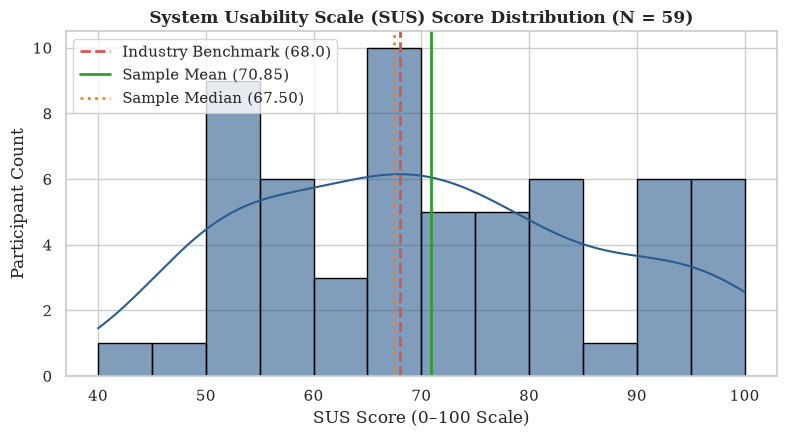

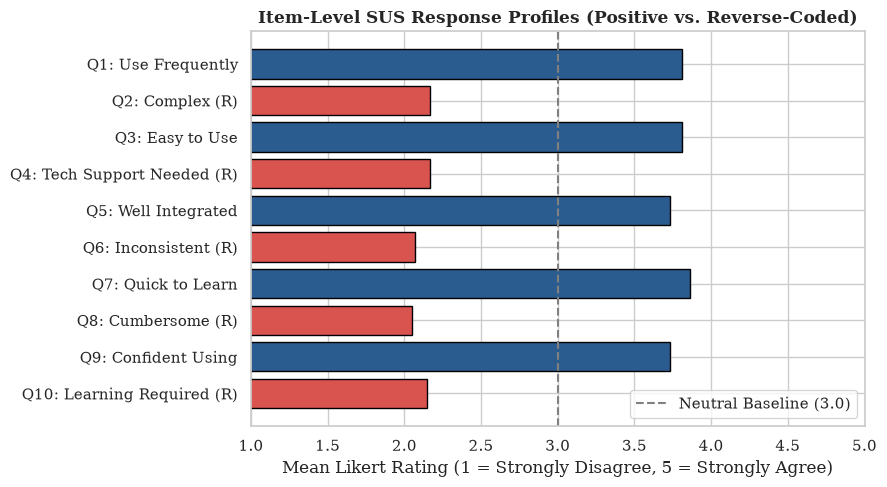

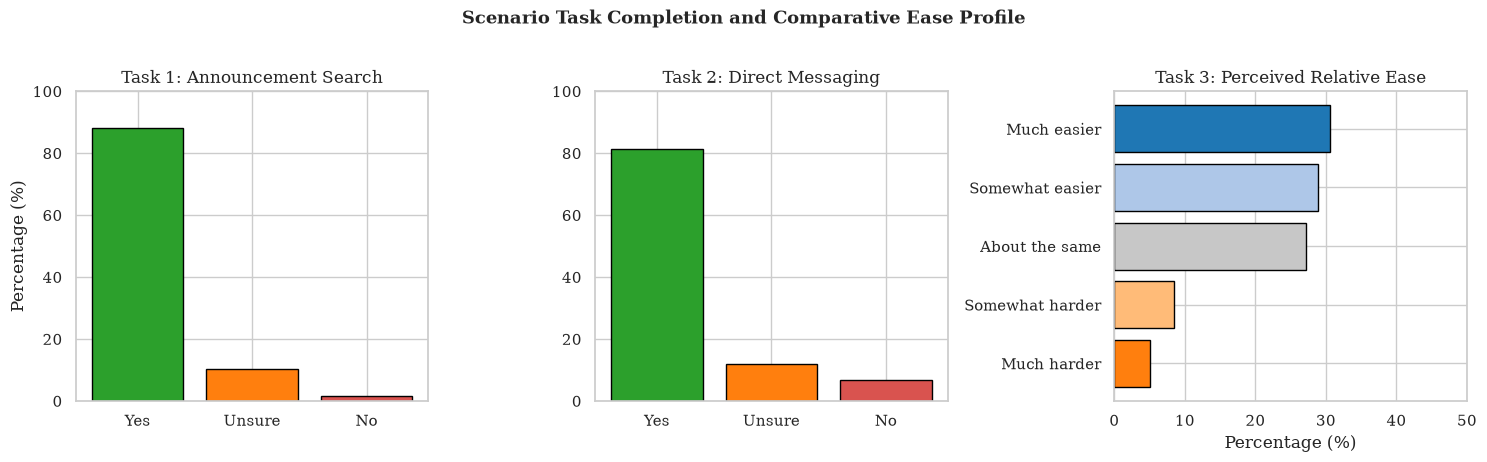

In [18]:
# 6. Existing Figures

import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../outputs/figures/phase2', exist_ok=True)

# Set aesthetics for academic reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "font.family": "serif"})

# ---------------------------------------------------------
# Figure 1: SUS Score Distribution with Benchmark Overlays
# ---------------------------------------------------------
plt.figure(figsize=(8, 4.5))
ax = sns.histplot(
    clean_sus, kde=True, color="#2b5c8f", bins=12, edgecolor="black", alpha=0.6
)
plt.axvline(
    68.0,
    color="#d9534f",
    linestyle="--",
    linewidth=2,
    label="Industry Benchmark (68.0)",
)
plt.axvline(
    mean_sus,
    color="#2ca02c",
    linestyle="-",
    linewidth=2,
    label=f"Sample Mean ({mean_sus:.2f})",
)
plt.axvline(
    median_sus,
    color="#ff7f0e",
    linestyle=":",
    linewidth=2,
    label=f"Sample Median ({median_sus:.2f})",
)

plt.title(
    "System Usability Scale (SUS) Score Distribution (N = 59)", fontweight="bold"
)
plt.xlabel("SUS Score (0–100 Scale)")
plt.ylabel("Participant Count")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/figures/phase2/sus_distribution.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Figure 2: SUS Item Mean Breakdown
# ---------------------------------------------------------
item_labels = [
    "Q1: Use Frequently",
    "Q2: Complex (R)",
    "Q3: Easy to Use",
    "Q4: Tech Support Needed (R)",
    "Q5: Well Integrated",
    "Q6: Inconsistent (R)",
    "Q7: Quick to Learn",
    "Q8: Cumbersome (R)",
    "Q9: Confident Using",
    "Q10: Learning Required (R)",
]

item_df = pd.DataFrame(item_stats)
item_df["Label"] = item_labels
# Color odd items (positive) differently from even items (reverse-coded negative)
colors = [
    "#2b5c8f" if i % 2 == 1 else "#d9534f" for i in range(1, 11)
]  # Blue = Positive, Red = Negative

plt.figure(figsize=(9, 5))
bars = plt.barh(
    item_df["Label"], item_df["Mean Rating"], color=colors, edgecolor="black"
)
plt.axvline(
    3.0,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Neutral Baseline (3.0)",
)

plt.xlim(1, 5)
plt.xlabel("Mean Likert Rating (1 = Strongly Disagree, 5 = Strongly Agree)")
plt.title(
    "Item-Level SUS Response Profiles (Positive vs. Reverse-Coded)",
    fontweight="bold",
)
plt.gca().invert_yaxis()  # Keep Q1 at top
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/figures/phase2/sus_item_means.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Figure 3: Task Completion & Relative Ease Metrics
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Task 1
t1_data = df["task1_announcements"].value_counts(normalize=True)[
    ["Yes", "Unsure", "No"]
] * 100
axes[0].bar(
    t1_data.index,
    t1_data.values,
    color=["#2ca02c", "#ff7f0e", "#d9534f"],
    edgecolor="black",
)
axes[0].set_title("Task 1: Announcement Search")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 100)

# Task 2
t2_data = df["task2_messaging"].value_counts(normalize=True)[
    ["Yes", "Unsure", "No"]
] * 100
axes[1].bar(
    t2_data.index,
    t2_data.values,
    color=["#2ca02c", "#ff7f0e", "#d9534f"],
    edgecolor="black",
)
axes[1].set_title("Task 2: Direct Messaging")
axes[1].set_ylim(0, 100)

# Task 3
ease_order = [
    "Much easier",
    "Somewhat easier",
    "About the same",
    "Somewhat harder",
    "Much harder",
]
t3_data = (
    df["task3_ease"].value_counts(normalize=True).reindex(ease_order) * 100
)
axes[2].barh(
    t3_data.index,
    t3_data.values,
    color=["#1f77b4", "#aec7e8", "#c7c7c7", "#ffbb78", "#ff7f0e"],
    edgecolor="black",
)
axes[2].set_title("Task 3: Perceived Relative Ease")
axes[2].set_xlabel("Percentage (%)")
axes[2].set_xlim(0, 50)
axes[2].invert_yaxis()

plt.suptitle(
    "Scenario Task Completion and Comparative Ease Profile",
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("../outputs/figures/phase2/task_metrics.png", dpi=300)
plt.show()